# Crop Recommendation and Yield Context (Machine Learning)

**Authors:** Vishal Anand, Aneesh Jain  
**Last updated:** 2026-04-26

This notebook provides:
- A clean, reproducible workflow to train a crop recommendation model from soil + weather features.
- Exploratory analysis across all provided CSV datasets to understand relationships and context.
- A leakage-safe evaluation (cross-validation + holdout test) with clear metric explanations and charts.


## Datasets Used

This repository includes three tabular datasets:
- `Datasets/Crop_recommendation.csv` (primary supervised learning dataset)
- `Datasets/DistrictWiseRainfallNormal.csv` (rainfall context by district)
- `Datasets/IndiaAgricultureCropProduction.csv` (production/yield context across years)

**Important note on relationships:** the rainfall and production datasets do not share a clean join key with the crop recommendation dataset in this repo. We analyze them as supporting context (rainfall patterns and yield trends). A future improvement would be to create a standardized district/state mapping to merge datasets reliably.


## Reproducibility

- All dataset paths are loaded relative to the project root.
- Random seeds are fixed where relevant.
- Outputs are intentionally kept clean; re-run cells top-to-bottom to reproduce results.


In [6]:
# Core imports and plotting style
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import json
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120


In [7]:
# Load datasets with paths that work from either project root or the Models/ folder
def find_project_root(start: Path | None = None) -> Path:
    start = start or Path.cwd()
    for p in [start, *start.parents]:
        if (p / 'Datasets').exists() and (p / 'Models').exists():
            return p
    return start

root = find_project_root()
datasets_dir = root / 'Datasets'

paths = {
    'crop_reco': datasets_dir / 'Crop_recommendation.csv',
    'rainfall': datasets_dir / 'DistrictWiseRainfallNormal.csv',
    'production': datasets_dir / 'IndiaAgricultureCropProduction.csv',
}

df1 = pd.read_csv(paths['crop_reco'])
df2 = pd.read_csv(paths['rainfall'])
df3 = pd.read_csv(paths['production'])

print('Loaded:')
print(' - df1 (Crop recommendation):', df1.shape)
print(' - df2 (Rainfall):', df2.shape)
print(' - df3 (Production):', df3.shape)


Loaded:
 - df1 (Crop recommendation): (2200, 8)
 - df2 (Rainfall): (641, 19)
 - df3 (Production): (345407, 10)


## Dataset 1: Crop Recommendation (Training Dataset)

**Goal:** learn a mapping from soil + weather features to a crop label.

- Features: `N`, `P`, `K`, `temperature`, `humidity`, `ph`, `rainfall`
- Target: `label` (crop name)

This dataset is well-suited for multi-class classification.


In [8]:
# Basic data quality checks (df1)
from IPython.display import display

numeric_cols = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']
target_col = 'label'

display(df1.head())

missing = df1.isna().sum().sort_values(ascending=False)
print('Missing values (df1):')
display(missing[missing > 0] if (missing > 0).any() else pd.Series({'missing_values': 0}))

dup = int(df1.duplicated().sum())
print('Duplicate rows (df1):', dup)

for c in numeric_cols:
    df1[c] = pd.to_numeric(df1[c], errors='coerce')

print('Target classes:', df1[target_col].nunique())
display(df1[target_col].value_counts().head(10))


,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


Missing values (df1):


missing_values    0
dtype: int64

Duplicate rows (df1): 0
Target classes: 22


label
rice           100
maize          100
chickpea       100
kidneybeans    100
pigeonpeas     100
mothbeans      100
mungbean       100
blackgram      100
lentil         100
pomegranate    100
Name: count, dtype: int64

### Relationships and Feature Behavior (df1)

We visualize distributions and correlations to understand how soil nutrients and weather variables relate to each other and to the crop labels.

**Why this matters:** even though tree-based models can handle non-linear relationships, understanding correlations and ranges helps detect data issues (unexpected ranges, unit problems) and guides feature engineering.


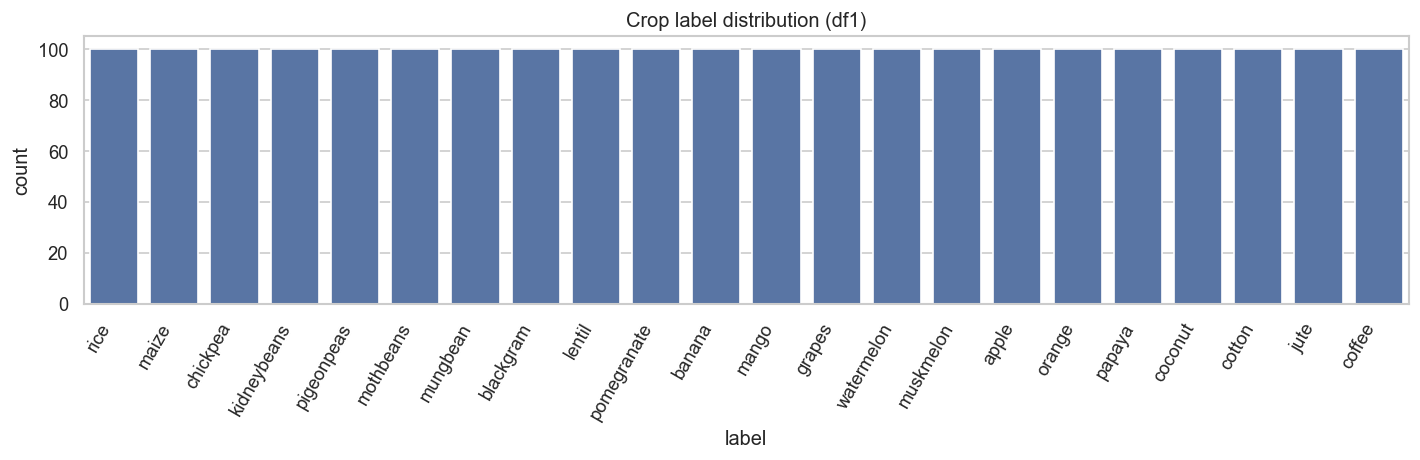

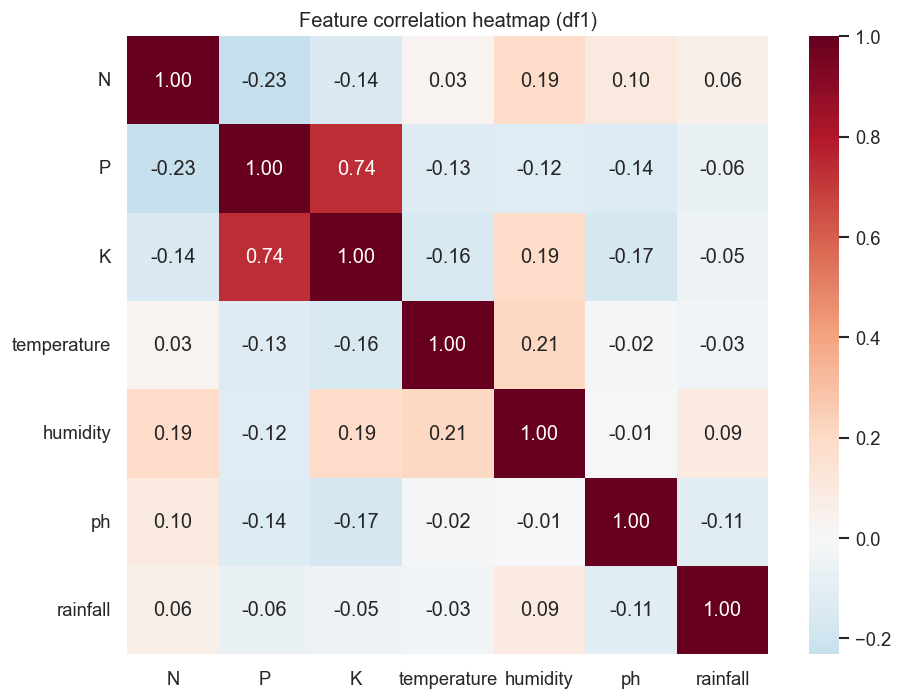

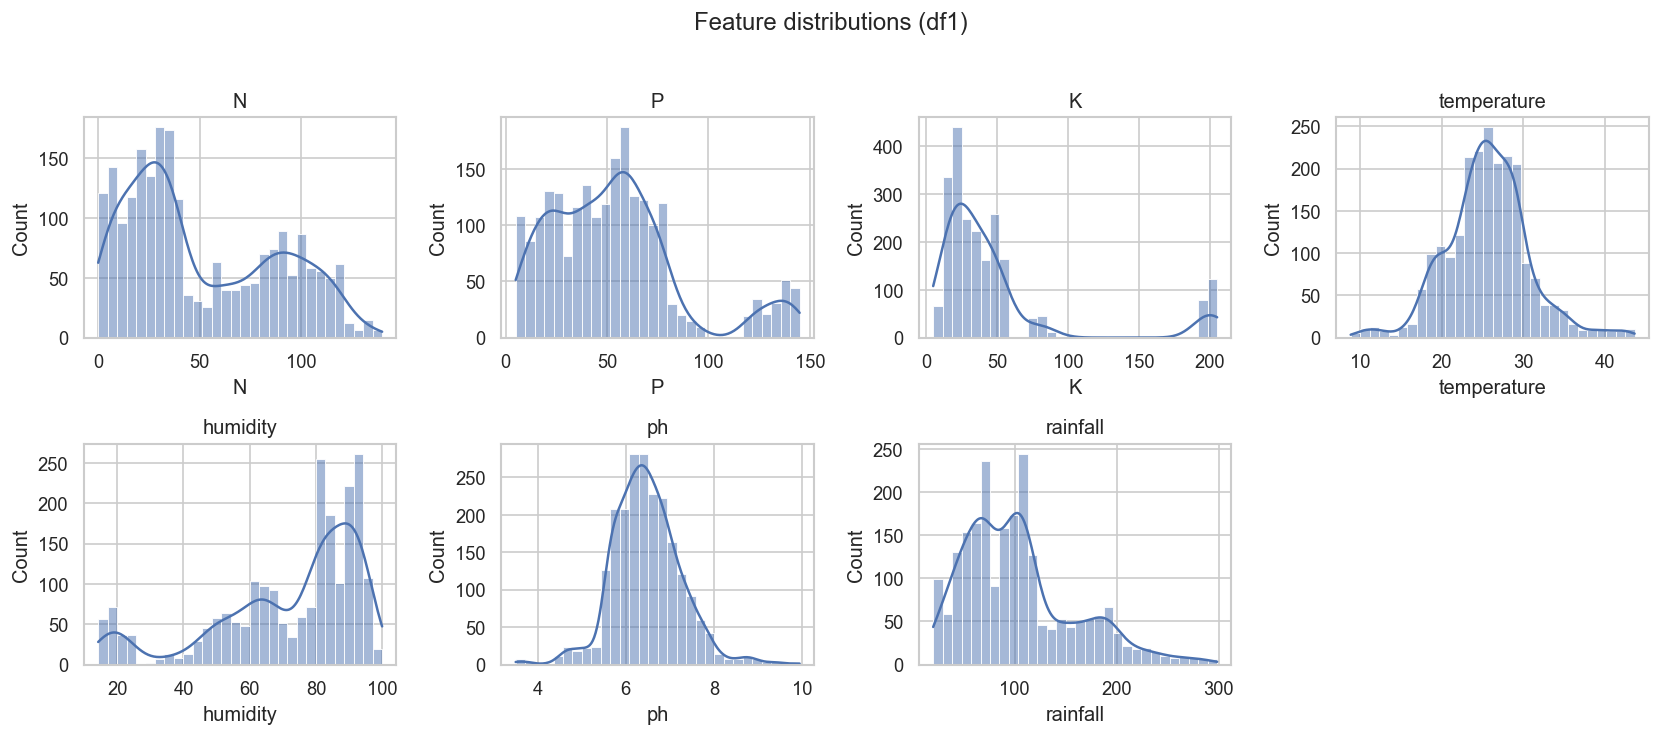

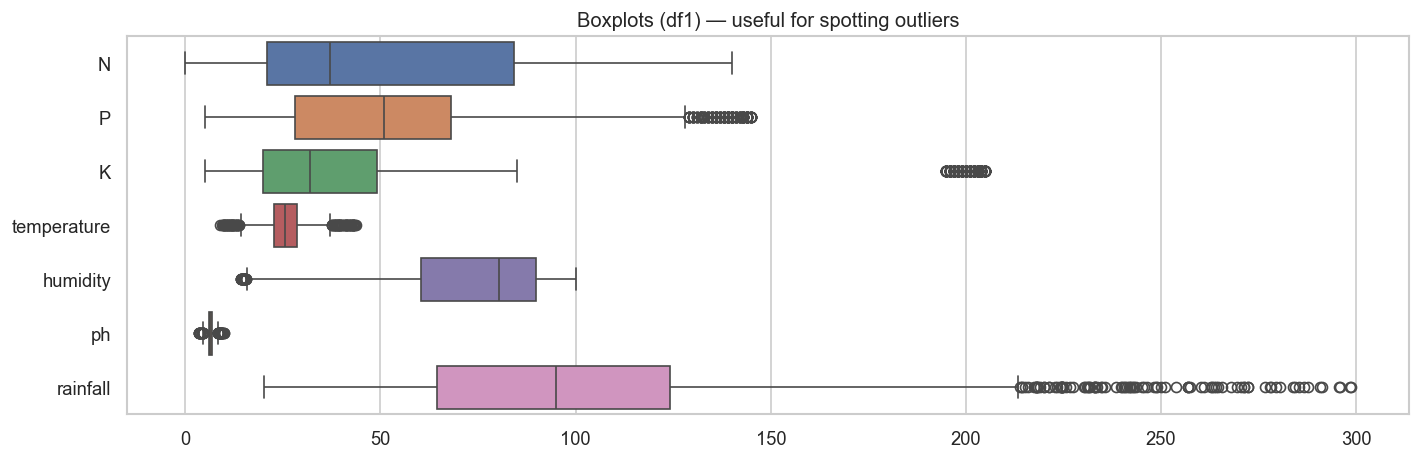

In [9]:
# EDA charts (df1)
plt.figure(figsize=(12, 4))
order = df1[target_col].value_counts().index
sns.countplot(data=df1, x=target_col, order=order)
plt.xticks(rotation=60, ha='right')
plt.title('Crop label distribution (df1)')
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
corr = df1[numeric_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0)
plt.title('Feature correlation heatmap (df1)')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 4, figsize=(14, 6))
axes = axes.ravel()
for i, c in enumerate(numeric_cols):
    sns.histplot(df1[c], kde=True, ax=axes[i], bins=30)
    axes[i].set_title(c)
for j in range(len(numeric_cols), len(axes)):
    axes[j].axis('off')
plt.suptitle('Feature distributions (df1)', y=1.02)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 4))
sns.boxplot(data=df1[numeric_cols], orient='h')
plt.title('Boxplots (df1) — useful for spotting outliers')
plt.tight_layout()
plt.show()


### What these charts suggest (df1)

- **Label distribution:** the dataset is balanced (each crop has the same number of rows), so we typically do not need class weighting to handle imbalance.
- **Correlation heatmap:** most features have low linear correlation, but **P and K are strongly correlated**. Tree-based models handle this well; linear models may treat them as partially redundant.
- **Histograms + KDE:** several features are non-normal or multi-modal, which is common in agronomic data collected across regions.
- **Boxplots:** visible outliers (especially in `rainfall`, `P`, and `K`) may represent real extreme conditions rather than errors. We treat outlier handling as a **data-quality decision** and validate against domain knowledge.


In [10]:
# Optional: IQR-based outlier counts (df1)
# This is a lightweight sanity check; for modeling we typically keep outliers unless they are measurement errors.

def detect_outliers_iqr(data: pd.DataFrame, column: str, k: float = 1.5) -> pd.Series:
    q1 = data[column].quantile(0.25)
    q3 = data[column].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - k * iqr
    upper_bound = q3 + k * iqr
    return (data[column] < lower_bound) | (data[column] > upper_bound)

outlier_counts = {c: int(detect_outliers_iqr(df1, c).sum()) for c in numeric_cols}
outlier_counts = pd.Series(outlier_counts).sort_values(ascending=False)
print('Outlier counts per feature (IQR method):')
display(outlier_counts)


Outlier counts per feature (IQR method):


K              200
P              138
rainfall       100
temperature     86
ph              57
humidity        30
N                0
dtype: int64

## Supporting Context from Other CSVs

The following analyses help establish domain context and relationships in the broader repository:
- Rainfall normals (`df2`) illustrate seasonality and regional rainfall patterns.
- Production/yield data (`df3`) shows yield distribution and trends across years/crops.

These do **not** directly train the crop recommendation model in this notebook (no clean join key provided), but they support interpretation and future feature expansion.


,STATE_UT_NAME,DISTRICT,JAN,FEB,MAR,APR,MAY,JUN,JUL,AUG,SEP,OCT,NOV,DEC,ANNUAL,Jan-Feb,Mar-May,Jun-Sep,Oct-Dec
0,ANDAMAN And NICOBAR ISLANDS,NICOBAR,107.3,57.9,65.2,117.0,358.5,295.5,285.0,271.9,354.8,326.0,315.2,250.9,2805.2,165.2,540.7,1207.2,892.1
1,ANDAMAN And NICOBAR ISLANDS,SOUTH ANDAMAN,43.7,26.0,18.6,90.5,374.4,457.2,421.3,423.1,455.6,301.2,275.8,128.3,3015.7,69.7,483.5,1757.2,705.3
2,ANDAMAN And NICOBAR ISLANDS,N & M ANDAMAN,32.7,15.9,8.6,53.4,343.6,503.3,465.4,460.9,454.8,276.1,198.6,100.0,2913.3,48.6,405.6,1884.4,574.7
3,ARUNACHAL PRADESH,LOHIT,42.2,80.8,176.4,358.5,306.4,447.0,660.1,427.8,313.6,167.1,34.1,29.8,3043.8,123.0,841.3,1848.5,231.0
4,ARUNACHAL PRADESH,EAST SIANG,33.3,79.5,105.9,216.5,323.0,738.3,990.9,711.2,568.0,206.9,29.5,31.7,4034.7,112.8,645.4,3008.4,268.1


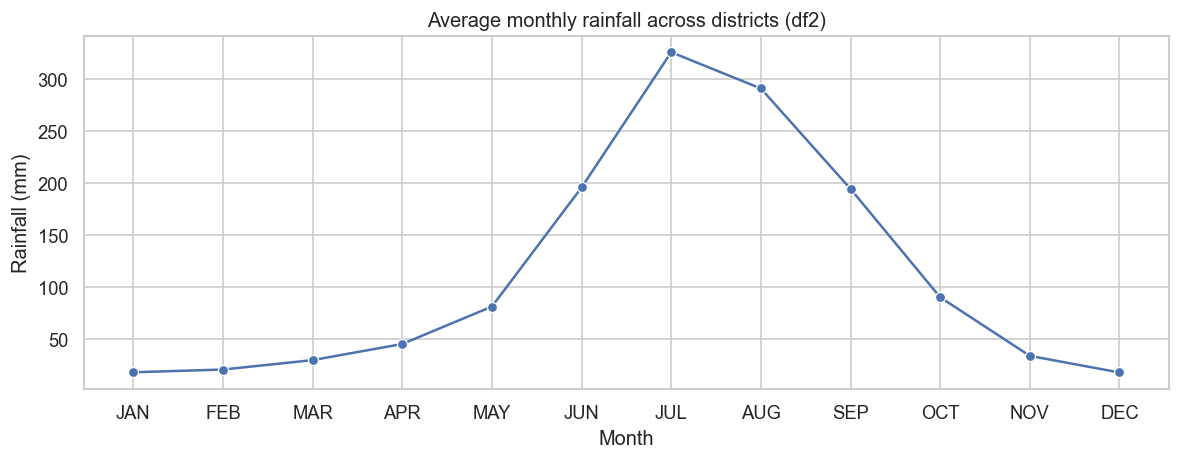

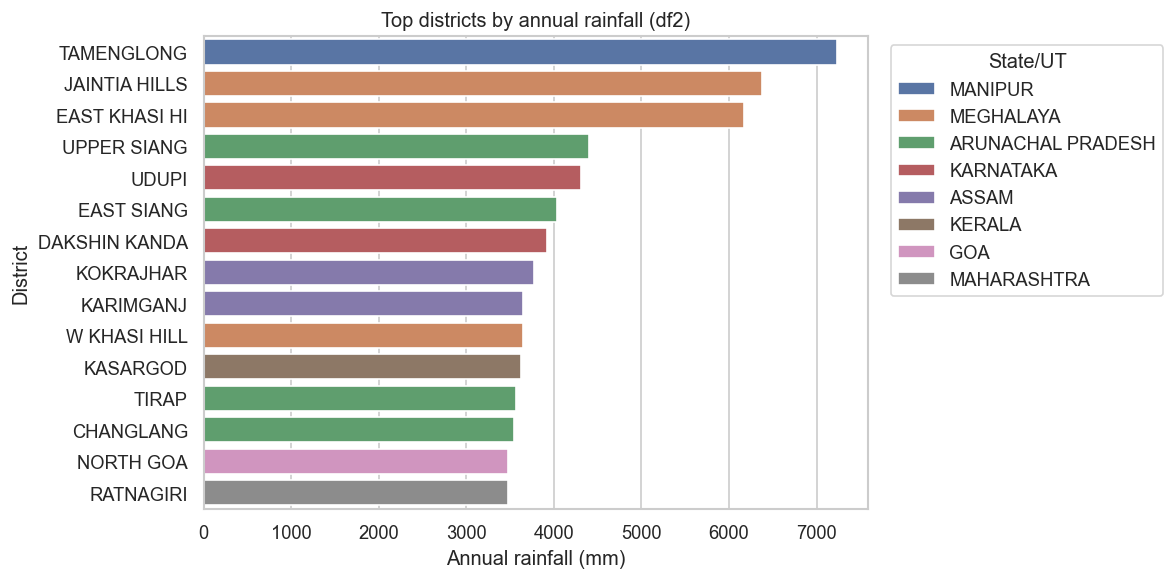

In [11]:
# Rainfall dataset (df2): quick profiling + charts
display(df2.head())

month_cols = ['JAN','FEB','MAR','APR','MAY','JUN','JUL','AUG','SEP','OCT','NOV','DEC']
available_months = [c for c in month_cols if c in df2.columns]

monthly_avg = df2[available_months].mean(numeric_only=True)
plt.figure(figsize=(10, 4))
sns.lineplot(x=monthly_avg.index, y=monthly_avg.values, marker='o')
plt.title('Average monthly rainfall across districts (df2)')
plt.xlabel('Month')
plt.ylabel('Rainfall (mm)')
plt.tight_layout()
plt.show()

if 'ANNUAL' in df2.columns:
    top = df2[['STATE_UT_NAME', 'DISTRICT', 'ANNUAL']].sort_values('ANNUAL', ascending=False).head(15)
    plt.figure(figsize=(10, 5))
    sns.barplot(data=top, y='DISTRICT', x='ANNUAL', hue='STATE_UT_NAME', dodge=False)
    plt.title('Top districts by annual rainfall (df2)')
    plt.xlabel('Annual rainfall (mm)')
    plt.ylabel('District')
    plt.legend(title='State/UT', bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.tight_layout()
    plt.show()


,State,District,Crop,Year,Season,Area,Area Units,Production,Production Units,Yield
0,Andaman and Nicobar Islands,NICOBARS,Arecanut,2001-02,Kharif,1254.0,Hectare,2061.0,Tonnes,1.643541
1,Andaman and Nicobar Islands,NICOBARS,Arecanut,2002-03,Whole Year,1258.0,Hectare,2083.0,Tonnes,1.655803
2,Andaman and Nicobar Islands,NICOBARS,Arecanut,2003-04,Whole Year,1261.0,Hectare,1525.0,Tonnes,1.209358
3,Andaman and Nicobar Islands,NORTH AND MIDDLE ANDAMAN,Arecanut,2001-02,Kharif,3100.0,Hectare,5239.0,Tonnes,1.690000
4,Andaman and Nicobar Islands,SOUTH ANDAMANS,Arecanut,2002-03,Whole Year,3105.0,Hectare,5267.0,Tonnes,1.696296


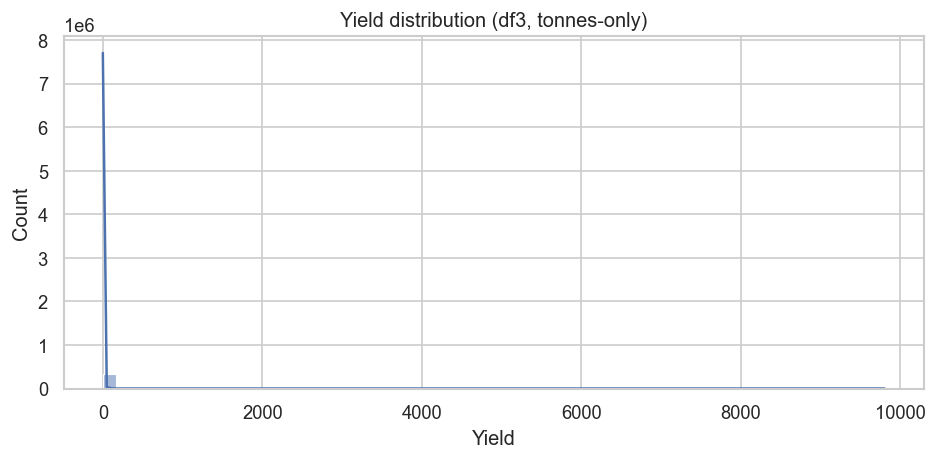

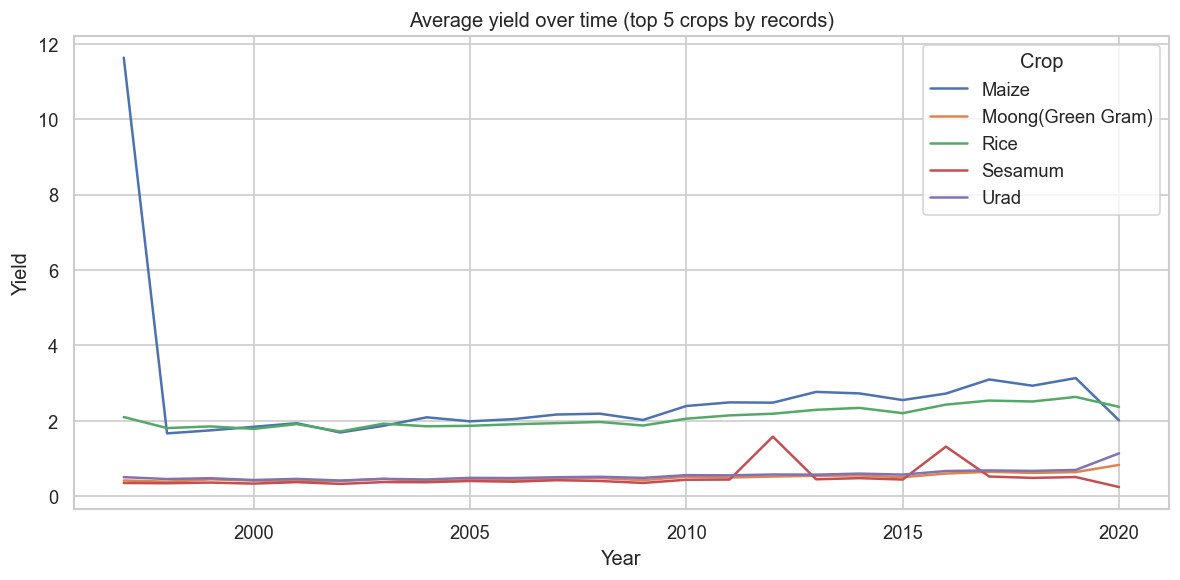

In [12]:
# Production dataset (df3): clean + yield context charts
display(df3.head())

df3_clean = df3.dropna(subset=['Area', 'Production', 'Yield']).copy()

if 'Production Units' in df3_clean.columns:
    df3_clean = df3_clean[df3_clean['Production Units'].astype(str).str.lower() == 'tonnes']

df3_clean['Year_start'] = df3_clean['Year'].astype(str).str.extract(r'(\d{4})', expand=False)
df3_clean['Year_start'] = pd.to_numeric(df3_clean['Year_start'], errors='coerce')
df3_clean = df3_clean.dropna(subset=['Year_start'])
df3_clean['Year_start'] = df3_clean['Year_start'].astype(int)

plt.figure(figsize=(8, 4))
sns.histplot(df3_clean['Yield'], bins=60, kde=True)
plt.title('Yield distribution (df3, tonnes-only)')
plt.xlabel('Yield')
plt.tight_layout()
plt.show()

top_crops = df3_clean['Crop'].value_counts().head(5).index
tmp = df3_clean[df3_clean['Crop'].isin(top_crops)].copy()
trend = tmp.groupby(['Year_start', 'Crop'], as_index=False)['Yield'].mean()
plt.figure(figsize=(10, 5))
sns.lineplot(data=trend, x='Year_start', y='Yield', hue='Crop')
plt.title('Average yield over time (top 5 crops by records)')
plt.xlabel('Year')
plt.tight_layout()
plt.show()


## Model Training: Crop Recommendation (df1)

### Approach
We frame crop recommendation as a **multi-class classification** problem.

We use an sklearn `Pipeline` to avoid data leakage:
- `SimpleImputer(strategy='median')` handles missing numeric values (fit on training only).
- `StandardScaler()` standardizes features for scale-sensitive models (SVM/LogReg).
- A classifier (tree-based / linear / SVM / ensemble).

### Evaluation design
- **Cross-validation on the training set**: estimates generalization and helps select a model.
- **Holdout test set**: final unbiased evaluation after selecting/tuning.


### Metrics Explained

For multi-class crop classification:
- **Accuracy**: fraction of correct predictions overall.
- **Precision** (per class): when the model predicts a crop, how often it is correct.
- **Recall** (per class): how many true examples of a crop were successfully found.
- **F1-score**: harmonic mean of precision and recall.
- **Macro F1**: average F1 across classes (treats all crops equally, good when you care about rare crops too).
- **Confusion matrix**: shows which crops are confused with others.


In [13]:
# Model selection with leakage-safe CV
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, classification_report, ConfusionMatrixDisplay

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, HistGradientBoostingClassifier
from sklearn.ensemble import StackingClassifier

RANDOM_STATE = 42

X = df1[numeric_cols].copy()
y = df1[target_col].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = {'acc': 'accuracy', 'f1_macro': 'f1_macro'}

def make_pipe(model):
    return Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('model', model),
    ])

base_models = {
    'logreg': LogisticRegression(max_iter=5000),
    'svm_rbf': SVC(kernel='rbf', probability=True, C=10.0, gamma='scale'),
    'random_forest': RandomForestClassifier(n_estimators=400, random_state=RANDOM_STATE, n_jobs=-1),
    'extra_trees': ExtraTreesClassifier(n_estimators=600, random_state=RANDOM_STATE, n_jobs=-1),
    'hist_gb': HistGradientBoostingClassifier(random_state=RANDOM_STATE),
}

# A unique model option: stacking ensemble (often strong on tabular problems)
stack = StackingClassifier(
    estimators=[
        ('rf', RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1)),
        ('et', ExtraTreesClassifier(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1)),
        ('lr', LogisticRegression(max_iter=5000)),
    ],
    final_estimator=LogisticRegression(max_iter=5000),
    stack_method='predict_proba',
    passthrough=False,
    n_jobs=-1,
)
base_models['stacking'] = stack

rows = []
for name, model in base_models.items():
    pipe = make_pipe(model)
    scores = cross_validate(
        pipe,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        error_score='raise',
        return_train_score=False,
    )
    rows.append({
        'model': name,
        'cv_acc_mean': float(np.mean(scores['test_acc'])),
        'cv_acc_std': float(np.std(scores['test_acc'])),
        'cv_f1_macro_mean': float(np.mean(scores['test_f1_macro'])),
        'cv_f1_macro_std': float(np.std(scores['test_f1_macro'])),
    })

results = pd.DataFrame(rows).sort_values('cv_f1_macro_mean', ascending=False)
display(results)

best_name = results.iloc[0]['model']
print('Selected by CV (best macro-F1):', best_name)


,model,cv_acc_mean,cv_acc_std,cv_f1_macro_mean,cv_f1_macro_std
5,stacking,0.993750,0.005207,0.993730,0.005226
2,random_forest,0.993182,0.005269,0.993146,0.005310
4,hist_gb,0.992614,0.004252,0.992624,0.004250
3,extra_trees,0.992614,0.005567,0.992553,0.005662
1,svm_rbf,0.982386,0.004888,0.982212,0.004895
0,logreg,0.968182,0.006577,0.967824,0.006765


Selected by CV (best macro-F1): stacking


In [14]:
# Hyperparameter tuning for the selected model (train only)
baseline_model = base_models[best_name]
pipe = make_pipe(baseline_model)

param_distributions = None
if best_name in {'extra_trees', 'random_forest'}:
    param_distributions = {
        'model__n_estimators': [400, 600, 800, 1000],
        'model__max_depth': [None, 10, 20, 30],
        'model__min_samples_split': [2, 4, 6, 8, 10],
        'model__min_samples_leaf': [1, 2, 3, 4],
        'model__max_features': ['sqrt', 'log2', None],
    }
elif best_name == 'svm_rbf':
    param_distributions = {
        'model__C': [0.5, 1, 3, 10, 30],
        'model__gamma': ['scale', 'auto'],
    }
elif best_name == 'logreg':
    param_distributions = {
        'model__C': [0.2, 0.5, 1, 2, 5, 10],
    }
elif best_name == 'hist_gb':
    param_distributions = {
        'model__learning_rate': [0.03, 0.05, 0.08, 0.1, 0.15],
        'model__max_depth': [2, 3, 4, 6, 8],
        'model__max_leaf_nodes': [15, 31, 63, 80],
        'model__min_samples_leaf': [10, 15, 20, 30],
    }

if param_distributions:
    search = RandomizedSearchCV(
        estimator=pipe,
        param_distributions=param_distributions,
        n_iter=25,
        scoring='f1_macro',
        cv=cv,
        n_jobs=-1,
        random_state=RANDOM_STATE,
        verbose=1,
    )
    search.fit(X_train, y_train)
    best_pipe = search.best_estimator_
    print('Best params:')
    print(search.best_params_)
    print(f'Best CV macro-F1: {search.best_score_:.4f}')
else:
    best_pipe = pipe.fit(X_train, y_train)
    print('No parameter search configured for this model; fitted baseline pipeline.')


No parameter search configured for this model; fitted baseline pipeline.


Holdout test accuracy: 0.9932
Holdout test macro-F1:  0.9932

Classification report:
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       1.00      1.00      1.00        20
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        20
      coffee       1.00      1.00      1.00        20
      cotton       1.00      1.00      1.00        20
      grapes       1.00      1.00      1.00        20
        jute       0.95      1.00      0.98        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       1.00      0.90      0.95        20
       maize       1.00      1.00      1.00        20
       mango       1.00      1.00      1.00        20
   mothbeans       0.91      1.00      0.95        20
    mungbean       1.00      1.00      1.00        20
   muskmelon       1.00      1.00      1.00       

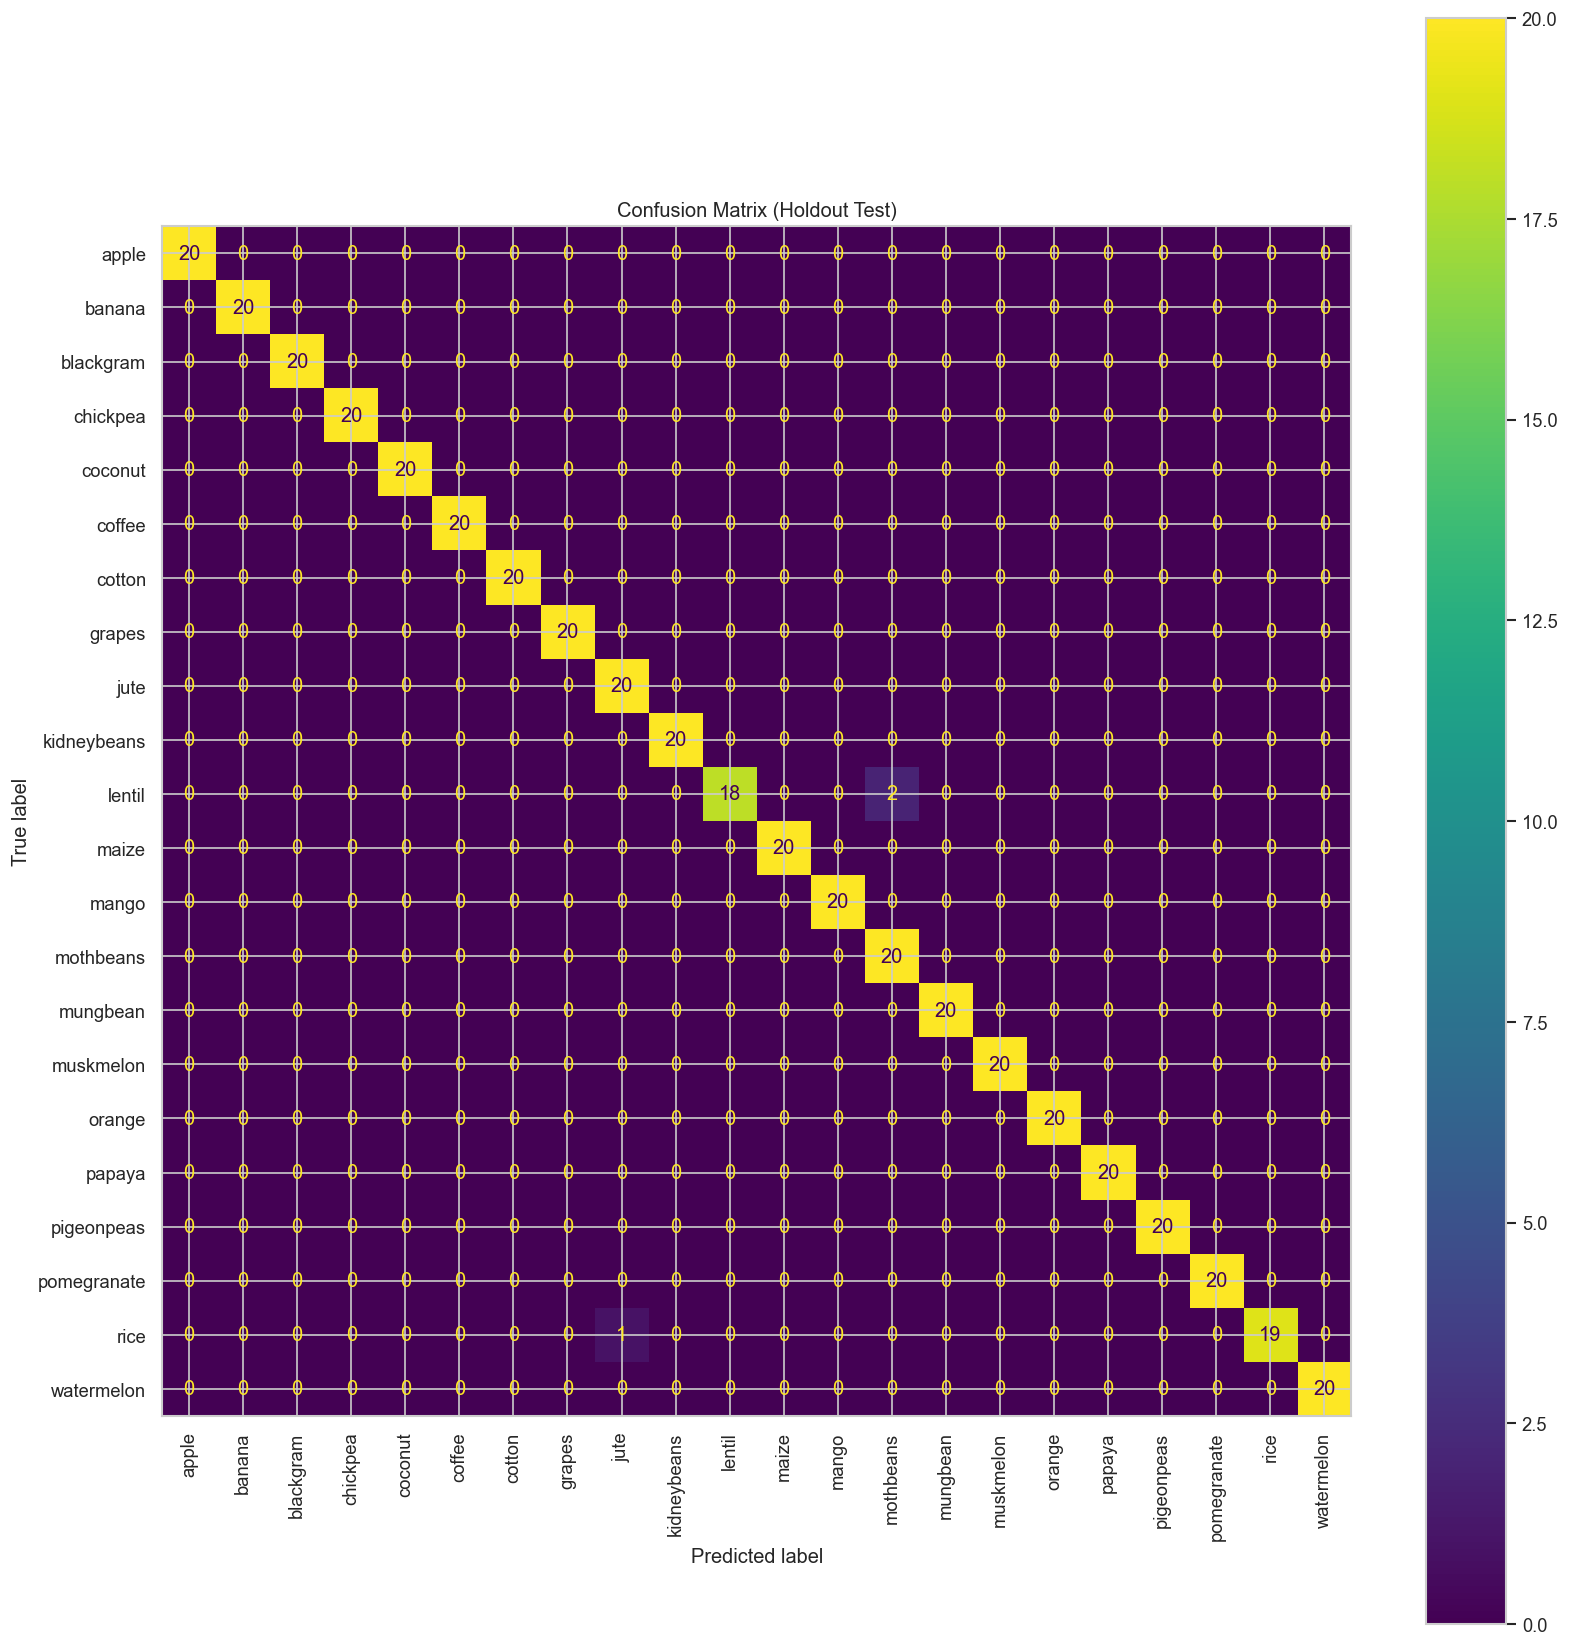

In [15]:
# Final evaluation on the holdout test set
y_pred = best_pipe.predict(X_test)
test_acc = accuracy_score(y_test, y_pred)
test_f1_macro = f1_score(y_test, y_pred, average='macro')

print(f'Holdout test accuracy: {test_acc:.4f}')
print(f'Holdout test macro-F1:  {test_f1_macro:.4f}')
print('\nClassification report:')
print(classification_report(y_test, y_pred))

disp = ConfusionMatrixDisplay.from_estimator(best_pipe, X_test, y_test, xticks_rotation='vertical')
disp.figure_.set_size_inches(14, 14)
disp.ax_.set_title('Confusion Matrix (Holdout Test)')
plt.tight_layout()
plt.show()


Feature importances not available for this model type.


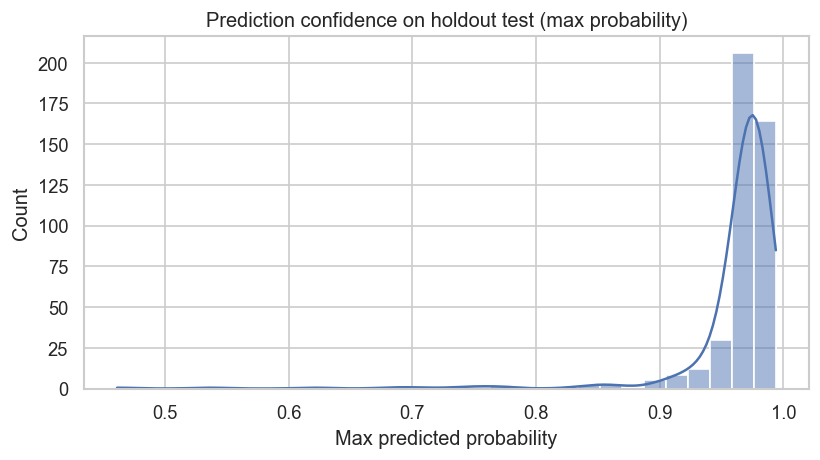

In [16]:
# Interpretability charts (when supported)
model = best_pipe.named_steps.get('model')

if hasattr(model, 'feature_importances_'):
    importances = pd.Series(model.feature_importances_, index=numeric_cols).sort_values(ascending=False)
    plt.figure(figsize=(8, 4))
    sns.barplot(x=importances.values, y=importances.index)
    plt.title('Feature importance (model)')
    plt.xlabel('Importance')
    plt.tight_layout()
    plt.show()
else:
    print('Feature importances not available for this model type.')

if hasattr(best_pipe, 'predict_proba'):
    proba = best_pipe.predict_proba(X_test)
    max_conf = proba.max(axis=1)
    plt.figure(figsize=(7, 4))
    sns.histplot(max_conf, bins=30, kde=True)
    plt.title('Prediction confidence on holdout test (max probability)')
    plt.xlabel('Max predicted probability')
    plt.tight_layout()
    plt.show()


In [17]:
# Save model artifacts
import joblib

art_dir = root / 'Models' / 'artifacts'
art_dir.mkdir(parents=True, exist_ok=True)

timestamp = datetime.now().strftime('%Y%m%d-%H%M%S')
model_path = art_dir / f'crop_recommendation_pipeline_{timestamp}.joblib'
meta_path = art_dir / f'crop_recommendation_metadata_{timestamp}.json'

joblib.dump(best_pipe, model_path)
with open(meta_path, 'w', encoding='utf-8') as f:
    json.dump({
        'features': numeric_cols,
        'target': target_col,
        'random_state': RANDOM_STATE,
        'cv': 'StratifiedKFold(n_splits=5, shuffle=True, random_state=42)',
        'selection_metric': 'f1_macro',
        'selected_model': str(best_name),
        'holdout_test_accuracy': float(test_acc),
        'holdout_test_f1_macro': float(test_f1_macro),
        'saved_model_path': str(model_path),
    }, f, indent=2)

print('Saved pipeline:', model_path)
print('Saved metadata:', meta_path)


Saved pipeline: e:\Machine Learning Project (College)\CSYP-ML\Models\artifacts\crop_recommendation_pipeline_20260426-133850.joblib
Saved metadata: e:\Machine Learning Project (College)\CSYP-ML\Models\artifacts\crop_recommendation_metadata_20260426-133850.json


## Using the Trained Model

The helper below shows how to generate a recommendation from a single input row.

Inputs are: `(N, P, K, temperature, humidity, ph, rainfall)`.


In [18]:
def recommend_crop(n, p, k, temperature, humidity, ph, rainfall):
    row = pd.DataFrame([[n, p, k, temperature, humidity, ph, rainfall]], columns=numeric_cols)
    return best_pipe.predict(row)[0]

example = (90, 42, 43, 20.9, 82.0, 6.5, 203.0)
print('Example input:', example)
print('Recommended crop:', recommend_crop(*example))


Example input: (90, 42, 43, 20.9, 82.0, 6.5, 203.0)
Recommended crop: rice
